### Imports

In [1]:
from pathlib import Path
import sys
import importlib
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import total_load_energy_analysis as tlea

importlib.reload(tlea)

<module 'src.total_load_energy_analysis' from 'c:\\Data_analysis\\Thesis\\src\\total_load_energy_analysis.py'>

### Settings

In [2]:
registry_path = Path(
    r"C:\Data_analysis\Thesis\outputs\profile_forecasting\best_prediction_files_registry.csv"
)

target_cols = [
    "BU_TotActPwr_Academy",
    "BU_TotActPwr_SDB_EL_Substation",
    "BU_TotActPwr_Tech_Room",
    "BA_TotActPwr_BESS_AC_Panel1",
    "BA_TotActPwr_BESS_AC_Panel2",
]

resolutions = ["15min", "30min", "60min"]
required_resolutions = set(resolutions)

### Load best sorted prediction registry

In [3]:
registry = tlea.load_best_prediction_registry(
    registry_path=registry_path,
    target_cols=target_cols,
    resolutions=resolutions,
)

display(registry[["target_col", "resolution", "model_name", "prediction_path"]])

,target_col,resolution,model_name,prediction_path
0,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,BA_TotActPwr_BESS_AC_Panel2,15min,xgboost,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,BU_TotActPwr_Academy,15min,xgboost,C:\Data_analysis\Thesis\outputs\profile_foreca...
3,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
4,BU_TotActPwr_Tech_Room,15min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
5,BA_TotActPwr_BESS_AC_Panel1,30min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
6,BA_TotActPwr_BESS_AC_Panel2,30min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
7,BU_TotActPwr_Academy,30min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...
8,BU_TotActPwr_SDB_EL_Substation,30min,ridge,C:\Data_analysis\Thesis\outputs\profile_foreca...
9,BU_TotActPwr_Tech_Room,30min,random_forest,C:\Data_analysis\Thesis\outputs\profile_foreca...


### Convert all best model predictions to long format

In [4]:
all_load_prediction_long = tlea.build_all_load_predictions_long(registry)

display(all_load_prediction_long.head())
print(all_load_prediction_long.shape)

,target_col,resolution,model_name,issue_time,forecast_date,time,actual_load_kW,ml_predicted_load_kW,constant_load_kW
0,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,2026-04-20 23:45:00,2026-04-21,2026-04-21 00:00:00,2.50900,2.390602,2.509
1,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,2026-04-20 23:45:00,2026-04-21,2026-04-21 00:15:00,2.51033,2.424550,2.509
2,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,2026-04-20 23:45:00,2026-04-21,2026-04-21 00:30:00,2.50933,2.700695,2.509
3,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,2026-04-20 23:45:00,2026-04-21,2026-04-21 00:45:00,2.50700,2.631219,2.509
4,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,2026-04-20 23:45:00,2026-04-21,2026-04-21 01:00:00,3.43133,2.507559,2.509


(10800, 9)


### Check complete dates per resolution

In [5]:
valid_dates_per_resolution = tlea.get_common_dates_per_resolution(
    all_load_prediction_long,
    target_cols=target_cols,
    resolutions=resolutions,
)

for resolution, dates in valid_dates_per_resolution.items():
    print(resolution, "common load dates:", len(dates))

15min common load dates: 7
30min common load dates: 9
60min common load dates: 8


### Build total actual, ML, and constant load

In [6]:
total_load_by_resolution = tlea.build_total_load_by_resolution(
    all_load_prediction_long,
    target_cols=target_cols,
    resolutions=resolutions,
    use_only_complete_load_days=True,
)

display(total_load_by_resolution.head())
print(total_load_by_resolution.shape)

,resolution,forecast_date,time,total_actual_load_kW,total_ml_predicted_load_kW,total_constant_load_kW,n_loads
0,15min,2026-04-23,2026-04-23 00:00:00,14.40500,13.929566,14.405,5
1,15min,2026-04-23,2026-04-23 00:15:00,14.10633,14.327484,14.405,5
2,15min,2026-04-23,2026-04-23 00:30:00,14.91967,13.397392,14.405,5
3,15min,2026-04-23,2026-04-23 00:45:00,13.99066,13.311117,14.405,5
4,15min,2026-04-23,2026-04-23 01:00:00,14.13667,12.316554,14.405,5


(1296, 7)


### Daily energy error

In [ ]:
total_energy_error_by_resolution = tlea.calculate_daily_energy_error(
    total_load_by_resolution,
    resolutions=resolutions,
)

# display(total_energy_error_by_resolution)

,resolution,forecast_date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%
0,30min,2026-04-22,405.882330,427.815424,391.85160,-21.933094,14.030730,21.933094,14.030730,5.403806,3.456847,-7.902364,-56.321834
1,15min,2026-04-23,414.212115,390.227550,345.72000,23.984565,68.492115,23.984565,68.492115,5.790406,16.535517,44.507550,64.982006
2,30min,2026-04-23,414.000345,397.736013,342.13608,16.264332,71.864265,16.264332,71.864265,3.928579,17.358504,55.599933,77.367985
3,60min,2026-04-23,413.906410,395.421731,344.52984,18.484679,69.376570,18.484679,69.376570,4.465908,16.761415,50.891891,73.356021
4,15min,2026-04-24,392.051472,379.205761,385.34376,12.845712,6.707712,12.845712,6.707712,3.276537,1.710926,-6.137999,-91.506595
5,30min,2026-04-24,392.058450,408.772742,397.41192,-16.714292,-5.353470,16.714292,5.353470,4.263214,1.365478,-11.360822,-212.214170
6,60min,2026-04-24,392.143190,396.528826,380.38968,-4.385636,11.753510,4.385636,11.753510,1.118376,2.997250,7.367874,62.686588
7,15min,2026-04-25,334.068195,362.045455,327.78384,-27.977260,6.284355,27.977260,6.284355,8.374715,1.881159,-21.692905,-345.189046
8,30min,2026-04-25,334.078995,397.709167,318.30432,-63.630172,15.774675,63.630172,15.774675,19.046445,4.721840,-47.855497,-303.369148
9,60min,2026-04-25,334.122750,387.694635,321.86616,-53.571885,12.256590,53.571885,12.256590,16.033594,3.668290,-41.315295,-337.086378


### Summary using all available days

In [11]:
total_energy_summary = tlea.summarize_energy_error(
    total_energy_error_by_resolution,
    common_days=False,
)

display(total_energy_summary)

,resolution,n_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent
0,15min,7,376.953482,379.351176,338.041131,-2.397693,38.912351,17.561798,4.968149,41.650159,10.507401,24.088361,-68.782230
1,30min,9,378.086967,407.851655,342.135547,-29.764689,35.951420,33.378984,9.439241,40.854436,10.596671,7.475451,-105.671180
2,60min,8,374.663797,390.704397,330.220530,-16.040599,44.443267,29.863504,8.617179,48.126402,12.488603,18.262898,-47.532625


### Common dates across all resolutions

In [ ]:
total_energy_error_common_dates, common_dates_total = tlea.filter_common_dates_across_resolutions(
    total_energy_error_by_resolution,
    required_resolutions=required_resolutions,
)

print("Common dates across all resolutions:", len(common_dates_total))
print(common_dates_total)

# display(
#     total_energy_error_common_dates
#     .sort_values(["forecast_date", "resolution"])
# )

Common dates across all resolutions: 7
[datetime.date(2026, 4, 23), datetime.date(2026, 4, 24), datetime.date(2026, 4, 25), datetime.date(2026, 4, 26), datetime.date(2026, 4, 27), datetime.date(2026, 4, 28), datetime.date(2026, 4, 29)]


,resolution,forecast_date,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%
0,15min,2026-04-23,414.212115,390.227550,345.72000,23.984565,68.492115,23.984565,68.492115,5.790406,16.535517,44.507550,64.982006
1,30min,2026-04-23,414.000345,397.736013,342.13608,16.264332,71.864265,16.264332,71.864265,3.928579,17.358504,55.599933,77.367985
2,60min,2026-04-23,413.906410,395.421731,344.52984,18.484679,69.376570,18.484679,69.376570,4.465908,16.761415,50.891891,73.356021
3,15min,2026-04-24,392.051472,379.205761,385.34376,12.845712,6.707712,12.845712,6.707712,3.276537,1.710926,-6.137999,-91.506595
4,30min,2026-04-24,392.058450,408.772742,397.41192,-16.714292,-5.353470,16.714292,5.353470,4.263214,1.365478,-11.360822,-212.214170
5,60min,2026-04-24,392.143190,396.528826,380.38968,-4.385636,11.753510,4.385636,11.753510,1.118376,2.997250,7.367874,62.686588
6,15min,2026-04-25,334.068195,362.045455,327.78384,-27.977260,6.284355,27.977260,6.284355,8.374715,1.881159,-21.692905,-345.189046
7,30min,2026-04-25,334.078995,397.709167,318.30432,-63.630172,15.774675,63.630172,15.774675,19.046445,4.721840,-47.855497,-303.369148
8,60min,2026-04-25,334.122750,387.694635,321.86616,-53.571885,12.256590,53.571885,12.256590,16.033594,3.668290,-41.315295,-337.086378
9,15min,2026-04-26,318.057752,359.938711,327.64008,-41.880958,-9.582328,41.880958,9.582328,13.167721,3.012763,-32.298631,-337.064570


## Summary using only common dates

In [13]:
total_energy_summary_common_dates = tlea.summarize_energy_error(
    total_energy_error_common_dates,
    common_days=True,
)

display(total_energy_summary_common_dates)

,resolution,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent
0,15min,7,376.953482,379.351176,338.041131,-2.397693,38.912351,17.561798,4.968149,41.650159,10.507401,24.088361,-68.782230
1,30min,7,376.916886,405.437549,342.686914,-28.520662,34.229972,33.167614,9.518935,40.533849,10.344016,7.366235,-132.642284
2,60min,7,376.914090,388.993210,336.173177,-12.079120,40.740913,27.876725,8.105995,44.950210,11.472170,17.073485,-59.721540


### Plot mean energy error comparison

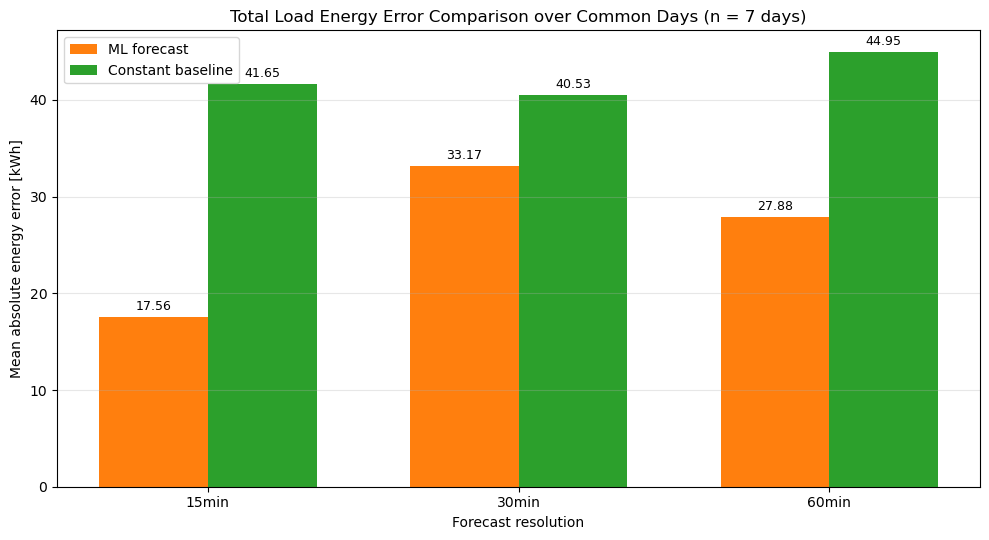

In [14]:
tlea.plot_energy_error_comparison(total_energy_summary_common_dates)

### Plot energy comparison for one selected day

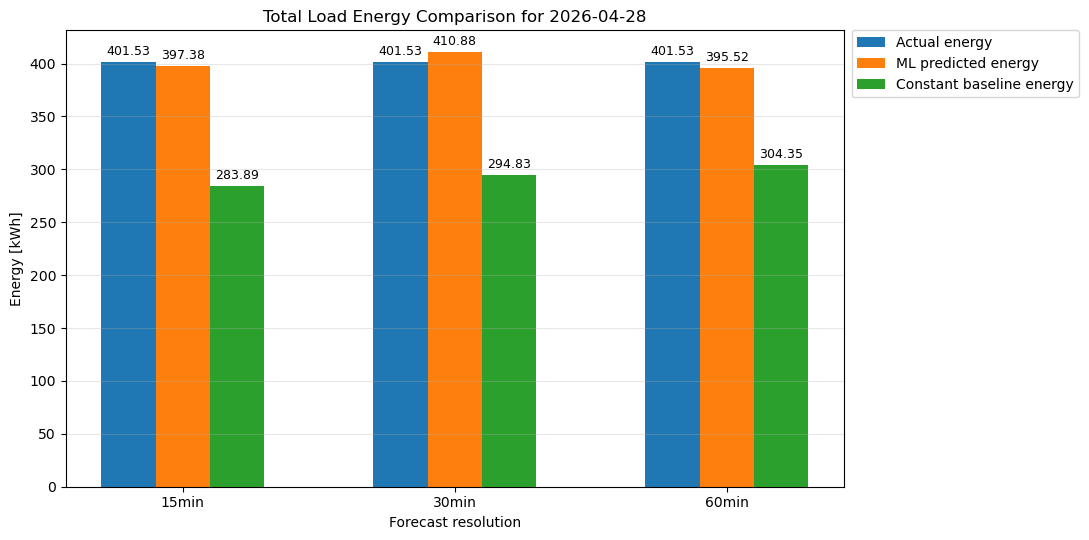

In [15]:
selected_day = "2026-04-28"

tlea.plot_energy_for_day(
    total_energy_error_common_dates,
    selected_day=selected_day,
)

### Actual load plus residual plot

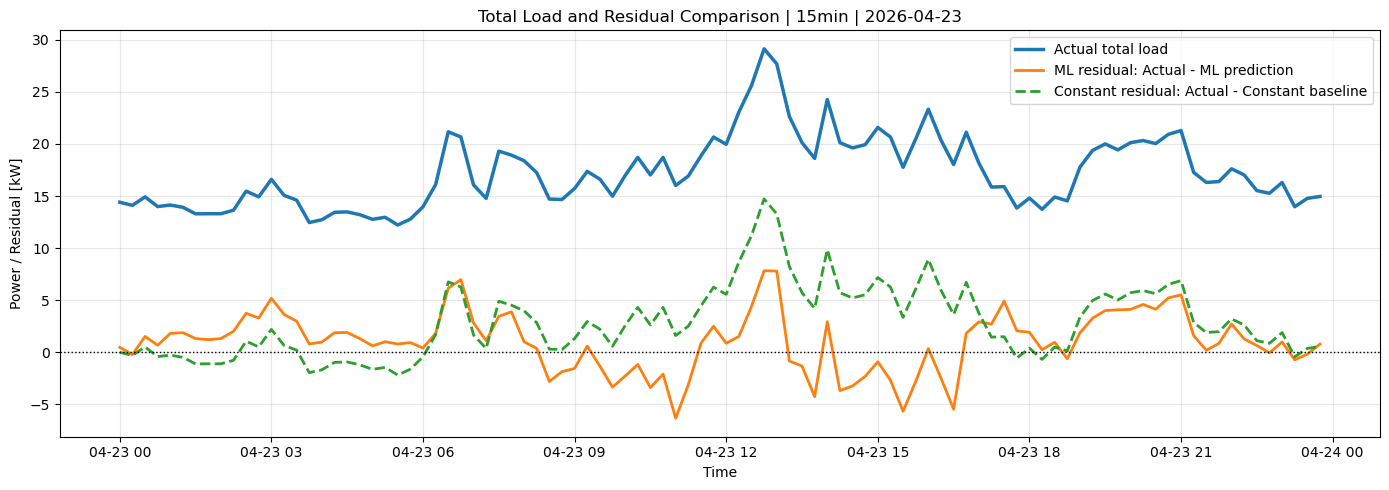

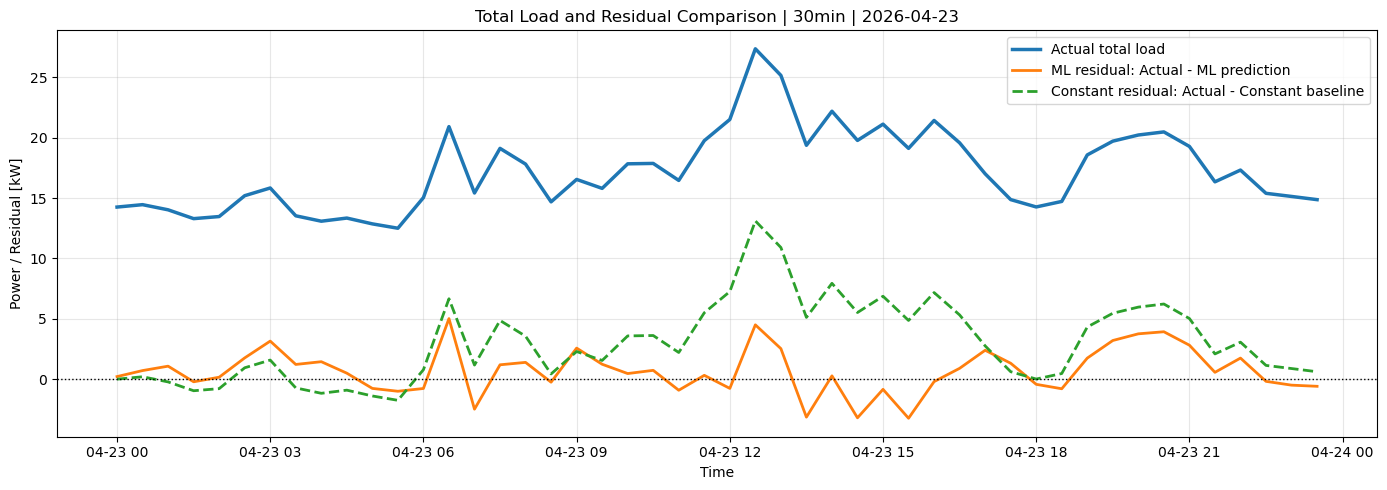

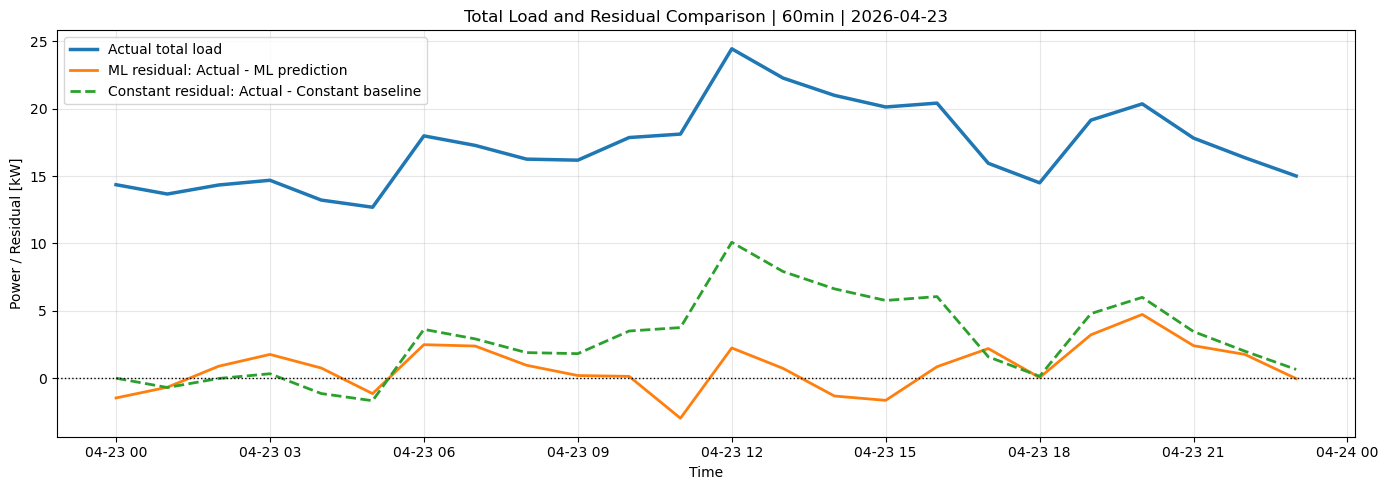

In [17]:
selected_day = "2026-04-23"

tlea.plot_residuals_for_day(
    total_load_by_resolution,
    selected_day=selected_day,
    include_actual=True,
    resolutions=resolutions,
)

## Bias and variance check

### Forecast bias and residual variance summary

In [18]:
bias_variance_summary = tlea.forecast_bias_variance_summary(
    total_load_by_resolution
)

display(bias_variance_summary)

,resolution,n_samples,mean_actual_load_kW,actual_std_kW,actual_cv,forecast_bias_kW,abs_forecast_bias_kW,residual_std_kW,residual_variance_kW2,MAE_kW,RMSE_kW,bias_share_of_MSE_%,variance_share_of_MSE_%
0,15min,672,15.706395,4.199481,0.267374,-0.099904,0.099904,3.767124,14.191227,2.656863,3.768449,0.070281,99.929719
1,30min,432,15.753624,4.350788,0.276177,-1.240195,1.240195,3.921092,15.374960,2.989581,4.112547,9.094072,90.905928
2,60min,192,15.610992,4.279899,0.274159,-0.668358,0.668358,3.886480,15.104730,2.861717,3.943530,2.872422,97.127578


| Resolution |    Bias meaning |             Variance meaning | Overall interpretation                                           |
| ---------- | --------------: | ---------------------------: | ---------------------------------------------------------------- |
| 15 min     | Very small bias |     Very high variance share | Best bias behavior, but errors fluctuate strongly                |
| 30 min     |    Highest bias | Still mostly variance-driven | Worst systematic overprediction among the three                  |
| 60 min     |   Moderate bias |       Mostly variance-driven | More balanced than 30 min, but still fluctuation error dominates |


Interpretation:
| Column                    | Meaning                                                                         |
| ------------------------- | ------------------------------------------------------------------------------- |
| `forecast_bias_kW`        | Mean residual. Positive means ML underpredicts. Negative means ML overpredicts. |
| `abs_forecast_bias_kW`    | Size of systematic bias.                                                        |
| `residual_std_kW`         | Error spread. Higher value means unstable error.                                |
| `residual_variance_kW2`   | Variance of residual error.                                                     |
| `bias_share_of_MSE_%`     | How much of MSE is caused by systematic bias.                                   |
| `variance_share_of_MSE_%` | How much of MSE is caused by residual fluctuation.                              |
| `actual_cv`               | Load variability. Higher value means the resolution/load is more dynamic.       |


### Plot bias and residual variance

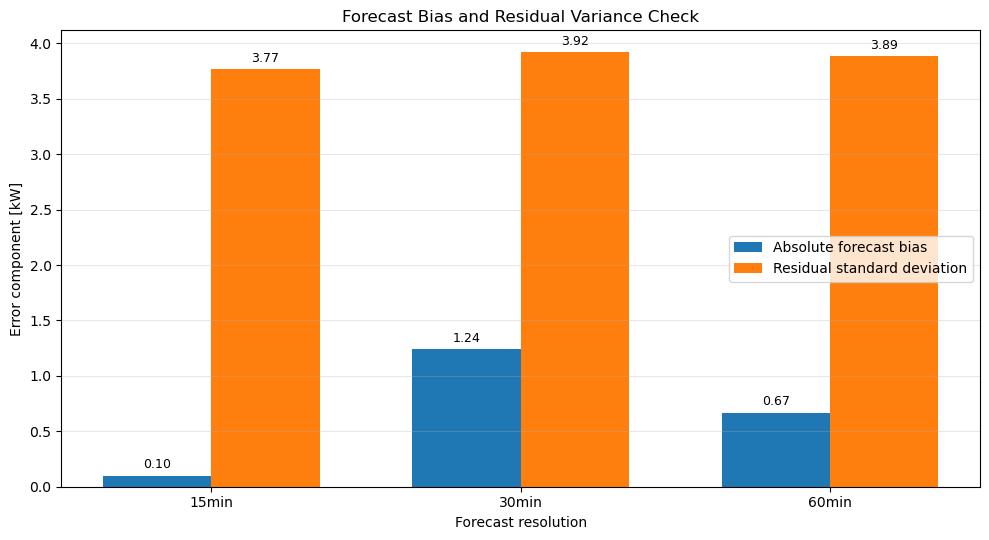

In [19]:
tlea.plot_bias_variance_summary(bias_variance_summary)

| Bias value | Meaning                   |
| ---------- | ------------------------- |
| Positive   | Model underpredicts       |
| Negative   | Model overpredicts        |
| Near zero  | No strong systematic bias |


| Resolution | Forecast bias [kW] | Meaning                                     |
| ---------- | -----------------: | ------------------------------------------- |
| 15 min     |              -0.10 | Almost unbiased, very slight overprediction |
| 30 min     |              -1.24 | Clear overprediction                        |
| 60 min     |              -0.67 | Moderate overprediction                     |



Residual standard deviation is high for all three:
| Resolution | Residual std [kW] |
| ---------- | ----------------: |
| 15 min     |              3.77 |
| 30 min     |              3.92 |
| 60 min     |              3.89 |
This means that even if the average bias is small, the prediction error still moves up and down significantly around zero.

| Resolution | Bias share of MSE | Variance share of MSE |
| ---------- | ----------------: | --------------------: |
| 15 min     |             0.07% |                99.93% |
| 30 min     |             9.09% |                90.91% |
| 60 min     |             2.87% |                97.13% |

The total forecasting error is not mainly caused by systematic model bias. It is mainly caused by residual variance, meaning irregular load fluctuations, timing mismatch, load spikes, and dynamic operating behavior that the model cannot fully capture.